In [1]:
# LIBRARIES AND SETTINGS
import numpy as np
import torch
from scipy.ndimage import gaussian_filter  
import matplotlib.pyplot as plt
import deepwave
from deepwave import scalar           # used to perform the forward modelling

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')       # to use the GPU if available
#device = torch.device('cpu')  # to use the cpu

# LOAD THE DATA
ny = 2301
nx = 751
vp = torch.from_file('marmousi_vp.bin',                            # Load the Marmousi velocity model
                         size=ny*nx).reshape(ny, nx).to(device)

# REDUCE THE VELOCITY MODEL SIZE
factor = 5   # Smoothing and subsampling factor
vp_np = vp.detach().cpu().numpy()
vp_smooth = gaussian_filter(vp_np, sigma=factor)

# Subsample
vp_reduced = vp_smooth[::factor, ::factor]
ny, nx = vp_reduced.shape   # New dimensions
dx, dy = 4.0 * factor, 4.0 * factor   #   4*5=20 m   #spacing in m

# Extent for models plotting
x_max = (ny - 1) * dx
z_max = (nx - 1) * dy
extent = [0, x_max, z_max, 0]

# TRUE VELOCITY MODEL
v_true = torch.from_numpy(vp_reduced).to(device)

# INITIAL VELOCITY MODEL (SMOOTHED TRUE MODEL)
v_init = (torch.tensor(1/gaussian_filter(1/v_true.cpu(), 25))
          .to(device))

# The smoothed velocity in another variable 
v1 = v_init.clone()   # This will be updated during FWI


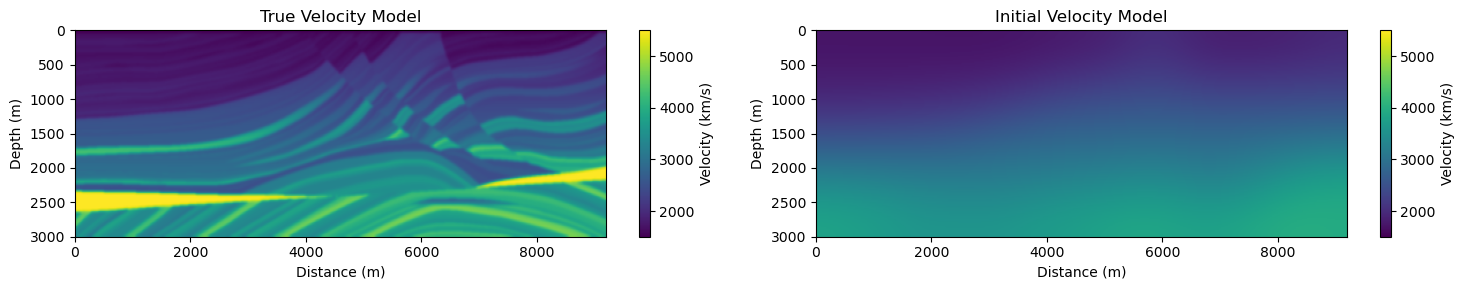

In [2]:
# PLOTTING THE TRUE AND INITIAL VELOCITY MODELS
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 3))
im1 = ax1.imshow(v_true.cpu().T, cmap='viridis', aspect='auto', vmin=v_true.min(), vmax=v_true.max(), extent=extent)
ax1.set_title('True Velocity Model')
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Depth (m)')

im2 = ax2.imshow(v_init.cpu().T, cmap='viridis', aspect='auto', vmin=v_true.min(), vmax=v_true.max(), extent=extent)
ax2.set_title('Initial Velocity Model')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Depth (m)')

fig1.colorbar(im1, ax=ax1, label='Velocity (km/s)')
fig1.colorbar(im2, ax=ax2, label='Velocity (km/s)')


plt.tight_layout()
plt.show()

In [3]:
# SOURCES
n_shots = 10
n_sources_per_shot = 1      
source_depth = 1         # 2 grid points * 4m = 8 m

# RECEIVERS
n_receivers_per_shot = 93     # Channels
receiver_depth = 1       # 2 * 4m = 8m

# PARAMETERS OF THE WAVELET 
freq = 5                 # Frequency of the wavelet in Hz
nt = 1350                # Number of time samples
dt = 0.004               # Sampling interval
peak_time = 1.5/freq

# SOURCE LOCATIONS
source_loc = torch.zeros(n_shots, n_sources_per_shot, 2,
                         dtype = torch.long, device = device)    
source_loc[..., 1] = source_depth
source_loc[:, 0, 0] = torch.linspace(0, ny - 1, n_shots).round()

# RECEIVERS LOCATIONS
receiver_loc = torch.zeros(n_shots, n_receivers_per_shot, 2, dtype=torch.long, device=device)
receiver_loc[..., 1] = receiver_depth
receiver_loc[:, :, 0] = torch.linspace(0, ny - 1, n_receivers_per_shot).round()


# SOURCE AMPLITUDES - RICKER WAVELET - 5 Hz
source_amp = (
            deepwave.wavelets.ricker(freq, nt, dt, peak_time)
            .repeat(n_shots, n_sources_per_shot, 1)
            .to(device)
            )

# FORWARD MODELLING FOR THE ACOUSTIC WAVE EQUATION
out_vel = scalar(v_true, dx, dt, source_amplitudes= source_amp,
                 source_locations= source_loc, receiver_locations= receiver_loc,
                 accuracy=4, pml_freq= freq)

observed_data = out_vel[-1]  # located in the last tensor of the output of the forward model

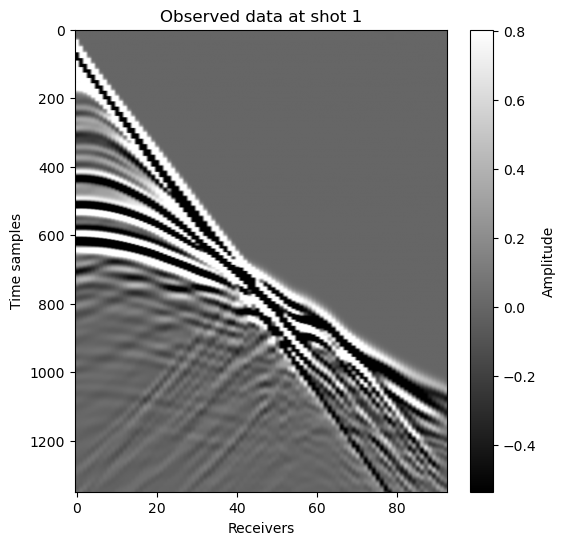

In [4]:
# PLOTTING THE OBSERVED DATA
shot_idx = 0
amin, amax = torch.quantile(observed_data[shot_idx], 
                            torch.tensor([0.05, 0.95]).to(device))
plt.figure(figsize=(6, 6))
plt.imshow(observed_data[shot_idx].cpu().T, cmap='gray', aspect='auto', vmin=amin, vmax=amax)
plt.xlabel('Receivers') ; plt.ylabel('Time samples')
plt.colorbar(label='Amplitude')
plt.title(f'Observed data at shot {shot_idx + 1}')
plt.show()

# plt.savefig('observed_data_shot_1.png', dpi = 300)  # uncomment to save the observed data

In [5]:
# FUNCTION TO TAPER THE ENDS OF TRACES
def taper(x):
    return deepwave.common.cosine_taper_end(x, 5)

# TAPER THE OBSERVED DATA
observed_data_1 = taper(observed_data)

# SET THE LOSS FUNCTION
loss_fn = torch.nn.MSELoss()


Epoch 1: loss=5.52157, v_min=1618.9, v_max=3994.1
Epoch 2: loss=3.10466, v_min=1524.4, v_max=4034.5
Epoch 3: loss=1.95810, v_min=1480.0, v_max=4065.2
Epoch 4: loss=1.35556, v_min=1480.0, v_max=4107.8
Epoch 5: loss=1.04094, v_min=1480.0, v_max=4145.9
Epoch 6: loss=0.88521, v_min=1480.0, v_max=4178.8
Epoch 7: loss=0.85562, v_min=1480.0, v_max=4205.5
Epoch 8: loss=0.85432, v_min=1480.0, v_max=4225.5
Epoch 9: loss=0.84060, v_min=1480.0, v_max=4239.4
Epoch 10: loss=0.82041, v_min=1480.0, v_max=4247.5
Epoch 11: loss=0.80228, v_min=1480.0, v_max=4251.0
Epoch 12: loss=0.78292, v_min=1480.0, v_max=4276.7
Epoch 13: loss=0.76496, v_min=1480.0, v_max=4326.0
Epoch 14: loss=0.74744, v_min=1480.0, v_max=4373.1
Epoch 15: loss=0.72711, v_min=1480.0, v_max=4418.7
Epoch 16: loss=0.70696, v_min=1480.0, v_max=4463.2
Epoch 17: loss=0.68672, v_min=1480.0, v_max=4506.7
Epoch 18: loss=0.66634, v_min=1480.0, v_max=4549.2
Epoch 19: loss=0.64594, v_min=1480.0, v_max=4590.4
Epoch 20: loss=0.62261, v_min=1480.0, v_

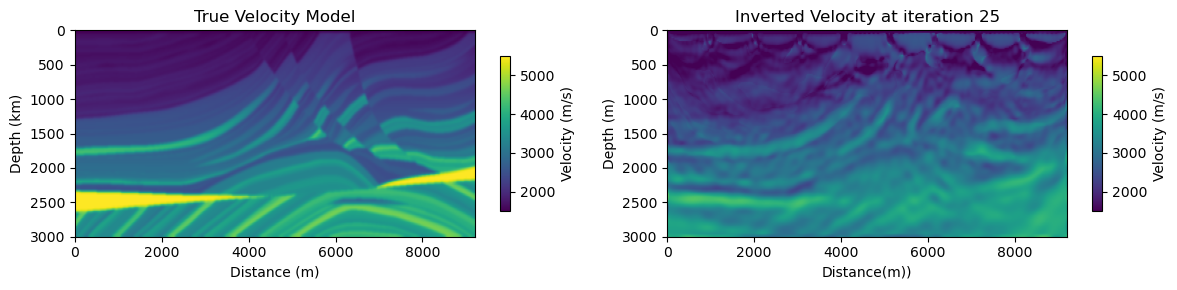

Epoch 26: loss=0.50428, v_min=1480.0, v_max=4822.0
Epoch 27: loss=0.48489, v_min=1480.0, v_max=4846.4
Epoch 28: loss=0.46523, v_min=1480.0, v_max=4869.0
Epoch 29: loss=0.44495, v_min=1480.0, v_max=4890.0
Epoch 30: loss=0.42534, v_min=1480.0, v_max=4909.7
Epoch 31: loss=0.40708, v_min=1480.0, v_max=4928.2
Epoch 32: loss=0.39043, v_min=1480.0, v_max=4945.7
Epoch 33: loss=0.37418, v_min=1480.0, v_max=4962.1
Epoch 34: loss=0.35813, v_min=1480.0, v_max=4977.5
Epoch 35: loss=0.34277, v_min=1480.0, v_max=4991.9
Epoch 36: loss=0.32823, v_min=1480.0, v_max=5005.2
Epoch 37: loss=0.31386, v_min=1480.0, v_max=5017.3
Epoch 38: loss=0.30050, v_min=1480.0, v_max=5028.0
Epoch 39: loss=0.28806, v_min=1480.0, v_max=5037.4
Epoch 40: loss=0.27627, v_min=1480.0, v_max=5045.6
Epoch 41: loss=0.26443, v_min=1480.0, v_max=5052.9
Epoch 42: loss=0.25317, v_min=1480.0, v_max=5059.4
Epoch 43: loss=0.24265, v_min=1480.0, v_max=5065.5
Epoch 44: loss=0.23251, v_min=1480.0, v_max=5071.0
Epoch 45: loss=0.22257, v_min=1

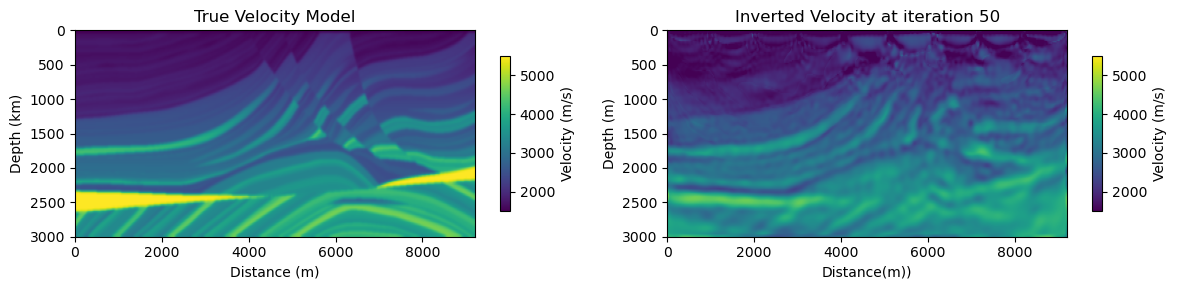

Epoch 51: loss=0.16718, v_min=1480.0, v_max=5102.8
Epoch 52: loss=0.15855, v_min=1480.0, v_max=5107.5
Epoch 53: loss=0.15014, v_min=1480.0, v_max=5112.2
Epoch 54: loss=0.14177, v_min=1480.0, v_max=5116.5
Epoch 55: loss=0.13341, v_min=1480.0, v_max=5120.5
Epoch 56: loss=0.12543, v_min=1480.0, v_max=5124.0
Epoch 57: loss=0.11771, v_min=1480.0, v_max=5127.1
Epoch 58: loss=0.11013, v_min=1480.0, v_max=5129.8
Epoch 59: loss=0.10271, v_min=1480.0, v_max=5132.0
Epoch 60: loss=0.09576, v_min=1480.0, v_max=5133.8
Epoch 61: loss=0.08919, v_min=1480.0, v_max=5135.3
Epoch 62: loss=0.08299, v_min=1480.0, v_max=5136.5
Epoch 63: loss=0.07716, v_min=1480.0, v_max=5137.4
Epoch 64: loss=0.07165, v_min=1480.0, v_max=5138.3
Epoch 65: loss=0.06644, v_min=1480.0, v_max=5139.1
Epoch 66: loss=0.06154, v_min=1480.0, v_max=5140.1
Epoch 67: loss=0.05690, v_min=1480.0, v_max=5141.3
Epoch 68: loss=0.05265, v_min=1480.0, v_max=5142.7
Epoch 69: loss=0.04874, v_min=1480.0, v_max=5144.3
Epoch 70: loss=0.04516, v_min=1

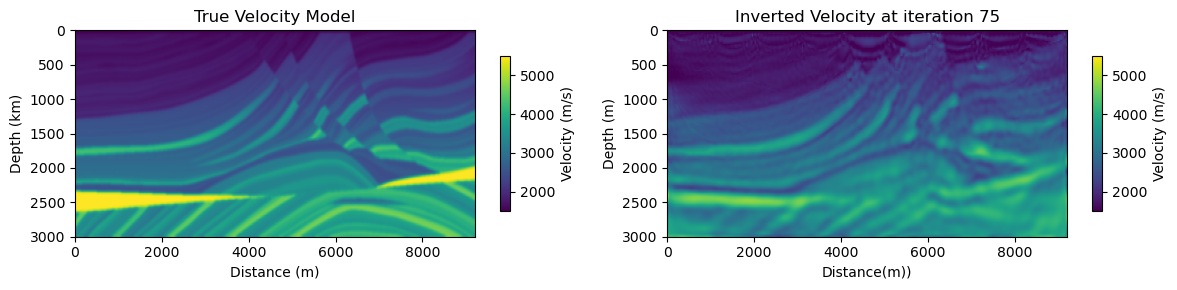

Epoch 76: loss=0.03000, v_min=1480.0, v_max=5160.5
Epoch 77: loss=0.03006, v_min=1480.0, v_max=5163.2
Epoch 78: loss=0.03178, v_min=1480.0, v_max=5165.5
Epoch 79: loss=0.03424, v_min=1480.0, v_max=5167.9
Epoch 80: loss=0.03165, v_min=1480.0, v_max=5169.7
Epoch 81: loss=0.02452, v_min=1480.0, v_max=5171.3
Epoch 82: loss=0.01895, v_min=1480.0, v_max=5172.6
Epoch 83: loss=0.02031, v_min=1480.0, v_max=5173.3
Epoch 84: loss=0.02348, v_min=1480.0, v_max=5173.8
Epoch 85: loss=0.02081, v_min=1480.0, v_max=5173.7
Epoch 86: loss=0.01543, v_min=1480.0, v_max=5173.3
Epoch 87: loss=0.01346, v_min=1480.0, v_max=5172.7
Epoch 88: loss=0.01533, v_min=1480.0, v_max=5171.9
Epoch 89: loss=0.01617, v_min=1480.0, v_max=5171.2
Epoch 90: loss=0.01306, v_min=1480.0, v_max=5170.4
Epoch 91: loss=0.01007, v_min=1480.0, v_max=5169.7
Epoch 92: loss=0.01027, v_min=1480.0, v_max=5169.1
Epoch 93: loss=0.01163, v_min=1480.0, v_max=5168.4
Epoch 94: loss=0.01136, v_min=1480.0, v_max=5168.0
Epoch 95: loss=0.00892, v_min=1

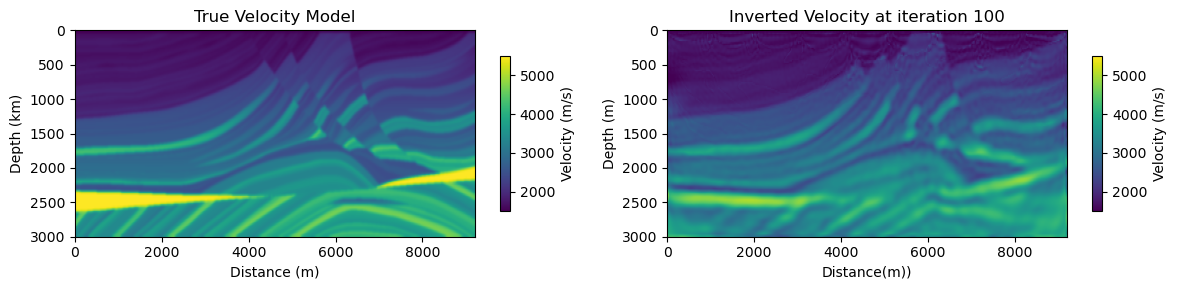

Epoch 101: loss=0.00530, v_min=1480.0, v_max=5168.1
Epoch 102: loss=0.00549, v_min=1480.0, v_max=5168.8
Epoch 103: loss=0.00604, v_min=1480.0, v_max=5169.6
Epoch 104: loss=0.00608, v_min=1480.0, v_max=5170.6
Epoch 105: loss=0.00528, v_min=1480.0, v_max=5171.6
Epoch 106: loss=0.00431, v_min=1480.0, v_max=5172.7
Epoch 107: loss=0.00392, v_min=1480.0, v_max=5173.7
Epoch 108: loss=0.00407, v_min=1480.0, v_max=5174.7
Epoch 109: loss=0.00430, v_min=1480.0, v_max=5175.5
Epoch 110: loss=0.00429, v_min=1480.0, v_max=5176.2
Epoch 111: loss=0.00396, v_min=1480.0, v_max=5176.9
Epoch 112: loss=0.00352, v_min=1480.0, v_max=5177.5
Epoch 113: loss=0.00312, v_min=1480.0, v_max=5178.1
Epoch 114: loss=0.00297, v_min=1480.0, v_max=5178.6
Epoch 115: loss=0.00305, v_min=1480.0, v_max=5179.1
Epoch 116: loss=0.00312, v_min=1480.0, v_max=5179.5
Epoch 117: loss=0.00314, v_min=1480.0, v_max=5179.7
Epoch 118: loss=0.00310, v_min=1480.0, v_max=5179.9
Epoch 119: loss=0.00294, v_min=1480.0, v_max=5179.9
Epoch 120: l

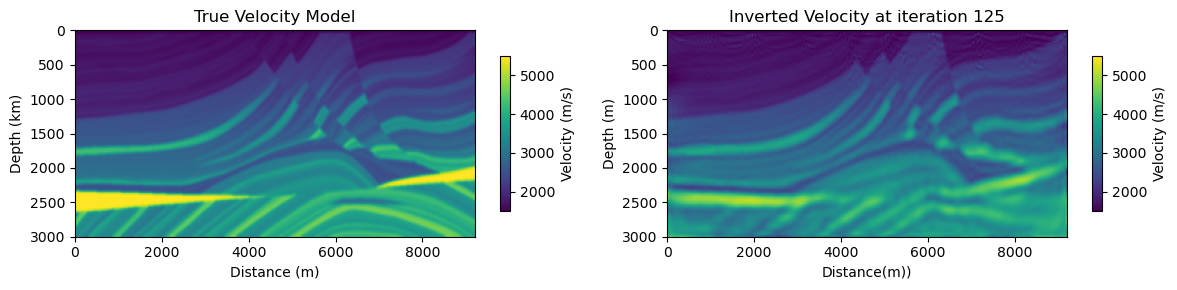

Epoch 126: loss=0.00205, v_min=1480.0, v_max=5177.1
Epoch 127: loss=0.00204, v_min=1480.0, v_max=5176.5
Epoch 128: loss=0.00208, v_min=1480.0, v_max=5175.8
Epoch 129: loss=0.00215, v_min=1480.0, v_max=5175.1
Epoch 130: loss=0.00228, v_min=1480.0, v_max=5174.3
Epoch 131: loss=0.00251, v_min=1480.0, v_max=5173.5
Epoch 132: loss=0.00296, v_min=1480.0, v_max=5172.5
Epoch 133: loss=0.00376, v_min=1480.0, v_max=5171.4
Epoch 134: loss=0.00506, v_min=1480.0, v_max=5170.1
Epoch 135: loss=0.00733, v_min=1480.0, v_max=5168.9
Epoch 136: loss=0.01004, v_min=1480.0, v_max=5167.5
Epoch 137: loss=0.01325, v_min=1480.0, v_max=5166.2
Epoch 138: loss=0.01319, v_min=1480.0, v_max=5164.7
Epoch 139: loss=0.01056, v_min=1480.0, v_max=5163.4
Epoch 140: loss=0.00508, v_min=1480.0, v_max=5161.9
Epoch 141: loss=0.00176, v_min=1480.0, v_max=5160.3
Epoch 142: loss=0.00236, v_min=1480.0, v_max=5161.8
Epoch 143: loss=0.00533, v_min=1480.0, v_max=5164.6
Epoch 144: loss=0.00782, v_min=1480.0, v_max=5166.8
Epoch 145: l

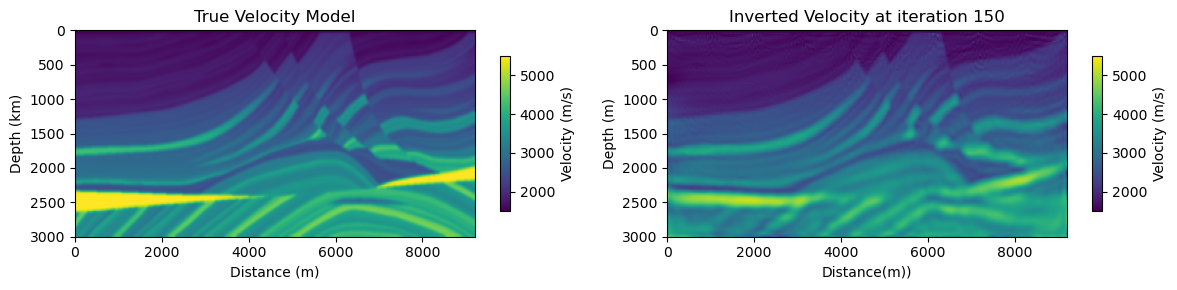

Epoch 151: loss=0.00505, v_min=1480.0, v_max=5183.3
Epoch 152: loss=0.00356, v_min=1480.0, v_max=5185.7
Epoch 153: loss=0.00196, v_min=1480.0, v_max=5187.8
Epoch 154: loss=0.00130, v_min=1480.0, v_max=5189.9
Epoch 155: loss=0.00218, v_min=1480.0, v_max=5192.3
Epoch 156: loss=0.00307, v_min=1480.0, v_max=5194.3
Epoch 157: loss=0.00320, v_min=1480.0, v_max=5196.7
Epoch 158: loss=0.00291, v_min=1480.0, v_max=5198.8
Epoch 159: loss=0.00189, v_min=1480.0, v_max=5201.0
Epoch 160: loss=0.00146, v_min=1480.0, v_max=5203.2
Epoch 161: loss=0.00204, v_min=1480.0, v_max=5205.3
Epoch 162: loss=0.00235, v_min=1480.0, v_max=5207.5
Epoch 163: loss=0.00261, v_min=1480.0, v_max=5209.4
Epoch 164: loss=0.00250, v_min=1480.0, v_max=5211.6
Epoch 165: loss=0.00200, v_min=1480.0, v_max=5213.5
Epoch 166: loss=0.00164, v_min=1480.0, v_max=5215.4
Epoch 167: loss=0.00141, v_min=1480.0, v_max=5217.4
Epoch 168: loss=0.00158, v_min=1480.0, v_max=5219.3
Epoch 169: loss=0.00179, v_min=1480.0, v_max=5221.3
Epoch 170: l

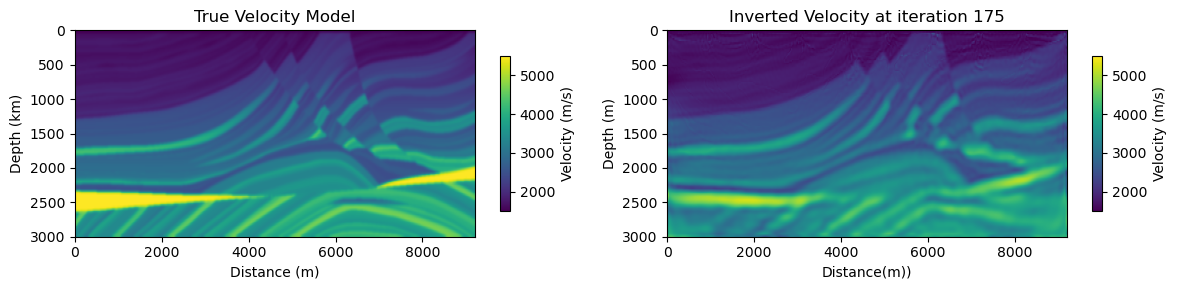

Epoch 176: loss=0.00133, v_min=1480.0, v_max=5234.5
Epoch 177: loss=0.00137, v_min=1480.0, v_max=5236.3
Epoch 178: loss=0.00140, v_min=1480.0, v_max=5238.2
Epoch 179: loss=0.00141, v_min=1480.0, v_max=5240.0
Epoch 180: loss=0.00140, v_min=1480.0, v_max=5241.9
Epoch 181: loss=0.00134, v_min=1480.0, v_max=5243.7
Epoch 182: loss=0.00123, v_min=1480.0, v_max=5245.5
Epoch 183: loss=0.00117, v_min=1480.0, v_max=5247.2
Epoch 184: loss=0.00116, v_min=1480.0, v_max=5249.0
Epoch 185: loss=0.00111, v_min=1480.0, v_max=5250.7
Epoch 186: loss=0.00104, v_min=1480.0, v_max=5252.6
Epoch 187: loss=0.00099, v_min=1480.0, v_max=5254.4
Epoch 188: loss=0.00100, v_min=1480.0, v_max=5256.2
Epoch 189: loss=0.00091, v_min=1480.0, v_max=5258.0
Epoch 190: loss=0.00089, v_min=1480.0, v_max=5259.9
Epoch 191: loss=0.00090, v_min=1480.0, v_max=5261.7
Epoch 192: loss=0.00086, v_min=1480.0, v_max=5263.5
Epoch 193: loss=0.00082, v_min=1480.0, v_max=5265.2
Epoch 194: loss=0.00082, v_min=1480.0, v_max=5266.9
Epoch 195: l

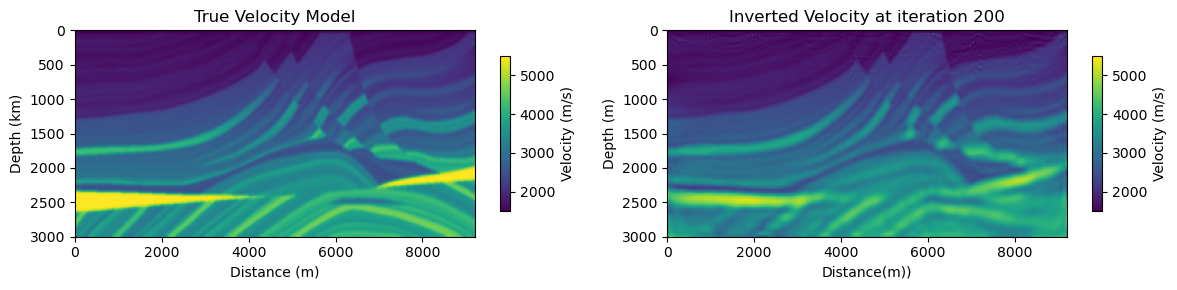

Epoch 201: loss=0.00196, v_min=1480.0, v_max=5277.7
Epoch 202: loss=0.00308, v_min=1480.0, v_max=5279.3
Epoch 203: loss=0.00599, v_min=1480.0, v_max=5280.4
Epoch 204: loss=0.01088, v_min=1480.9, v_max=5282.1
Epoch 205: loss=0.02128, v_min=1480.0, v_max=5282.8
Epoch 206: loss=0.03116, v_min=1480.8, v_max=5284.4
Epoch 207: loss=0.03649, v_min=1480.0, v_max=5284.6
Epoch 208: loss=0.01955, v_min=1481.2, v_max=5285.6
Epoch 209: loss=0.00416, v_min=1480.0, v_max=5286.4
Epoch 210: loss=0.00400, v_min=1480.0, v_max=5287.0
Epoch 211: loss=0.01493, v_min=1480.0, v_max=5288.3
Epoch 212: loss=0.02233, v_min=1480.0, v_max=5288.5
Epoch 213: loss=0.01307, v_min=1480.0, v_max=5289.5
Epoch 214: loss=0.00289, v_min=1480.0, v_max=5290.4
Epoch 215: loss=0.00508, v_min=1480.0, v_max=5290.9
Epoch 216: loss=0.01264, v_min=1480.0, v_max=5292.2
Epoch 217: loss=0.01343, v_min=1480.0, v_max=5292.7
Epoch 218: loss=0.00633, v_min=1480.0, v_max=5293.6
Epoch 219: loss=0.00241, v_min=1480.0, v_max=5294.7
Epoch 220: l

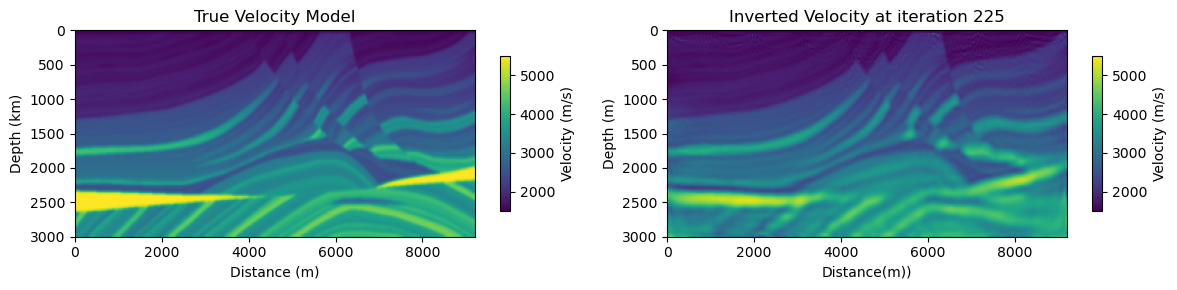

Epoch 226: loss=0.00619, v_min=1480.0, v_max=5302.4
Epoch 227: loss=0.00346, v_min=1480.0, v_max=5303.8
Epoch 228: loss=0.00312, v_min=1480.0, v_max=5305.0
Epoch 229: loss=0.00525, v_min=1480.0, v_max=5306.7
Epoch 230: loss=0.00535, v_min=1480.0, v_max=5307.9
Epoch 231: loss=0.00298, v_min=1480.0, v_max=5309.3
Epoch 232: loss=0.00233, v_min=1480.0, v_max=5310.8
Epoch 233: loss=0.00410, v_min=1480.0, v_max=5311.9
Epoch 234: loss=0.00424, v_min=1480.0, v_max=5313.3
Epoch 235: loss=0.00285, v_min=1480.0, v_max=5314.5
Epoch 236: loss=0.00220, v_min=1480.0, v_max=5315.6
Epoch 237: loss=0.00266, v_min=1480.0, v_max=5317.0
Epoch 238: loss=0.00338, v_min=1480.0, v_max=5318.3
Epoch 239: loss=0.00268, v_min=1480.0, v_max=5319.9
Epoch 240: loss=0.00180, v_min=1480.0, v_max=5321.4
Epoch 241: loss=0.00196, v_min=1480.0, v_max=5322.7
Epoch 242: loss=0.00224, v_min=1480.0, v_max=5324.3
Epoch 243: loss=0.00238, v_min=1480.0, v_max=5325.6
Epoch 244: loss=0.00197, v_min=1480.0, v_max=5327.1
Epoch 245: l

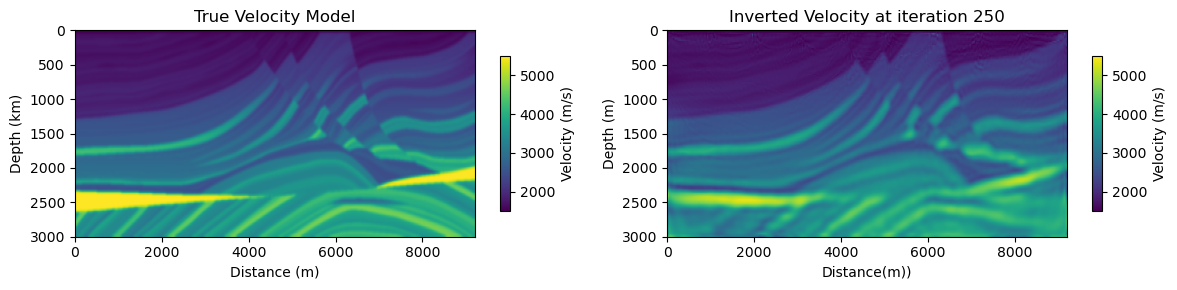

Epoch 251: loss=0.00139, v_min=1480.0, v_max=5337.3
Epoch 252: loss=0.00141, v_min=1480.0, v_max=5338.8
Epoch 253: loss=0.00153, v_min=1480.0, v_max=5340.2
Epoch 254: loss=0.00142, v_min=1480.0, v_max=5341.6
Epoch 255: loss=0.00106, v_min=1480.0, v_max=5343.0
Epoch 256: loss=0.00120, v_min=1480.0, v_max=5344.4
Epoch 257: loss=0.00132, v_min=1480.0, v_max=5345.8
Epoch 258: loss=0.00127, v_min=1480.0, v_max=5347.1
Epoch 259: loss=0.00115, v_min=1480.0, v_max=5348.4
Epoch 260: loss=0.00101, v_min=1480.0, v_max=5349.7
Epoch 261: loss=0.00098, v_min=1480.0, v_max=5351.0
Epoch 262: loss=0.00097, v_min=1480.0, v_max=5352.3
Epoch 263: loss=0.00099, v_min=1480.0, v_max=5353.5
Epoch 264: loss=0.00096, v_min=1480.0, v_max=5354.8
Epoch 265: loss=0.00092, v_min=1480.0, v_max=5356.0
Epoch 266: loss=0.00082, v_min=1480.0, v_max=5357.3
Epoch 267: loss=0.00078, v_min=1480.0, v_max=5358.6
Epoch 268: loss=0.00080, v_min=1480.0, v_max=5359.8
Epoch 269: loss=0.00083, v_min=1480.0, v_max=5361.2
Epoch 270: l

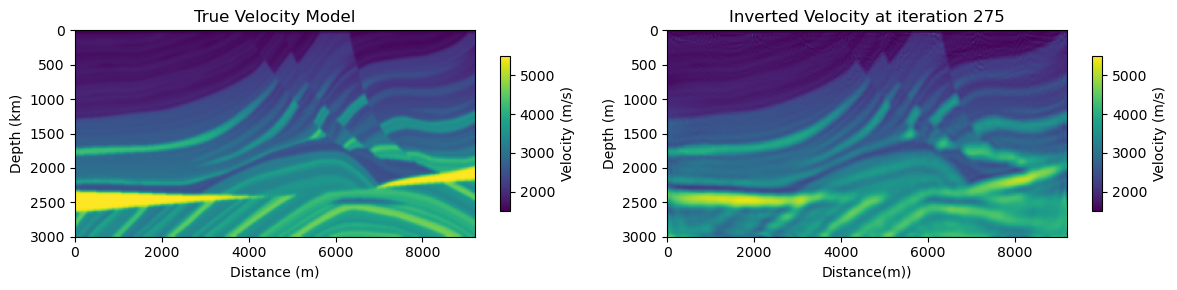

Epoch 276: loss=0.00062, v_min=1480.0, v_max=5369.9
Epoch 277: loss=0.00062, v_min=1480.0, v_max=5371.0
Epoch 278: loss=0.00056, v_min=1480.0, v_max=5372.2
Epoch 279: loss=0.00053, v_min=1480.0, v_max=5373.3
Epoch 280: loss=0.00051, v_min=1480.0, v_max=5374.4
Epoch 281: loss=0.00050, v_min=1480.0, v_max=5375.5
Epoch 282: loss=0.00050, v_min=1480.0, v_max=5376.6
Epoch 283: loss=0.00050, v_min=1480.0, v_max=5377.7
Epoch 284: loss=0.00048, v_min=1480.0, v_max=5378.8
Epoch 285: loss=0.00047, v_min=1480.0, v_max=5379.9
Epoch 286: loss=0.00045, v_min=1480.0, v_max=5381.0
Epoch 287: loss=0.00043, v_min=1480.0, v_max=5382.0
Epoch 288: loss=0.00041, v_min=1480.0, v_max=5383.1
Epoch 289: loss=0.00041, v_min=1480.0, v_max=5384.2
Epoch 290: loss=0.00040, v_min=1480.0, v_max=5385.2
Epoch 291: loss=0.00040, v_min=1480.0, v_max=5386.2
Epoch 292: loss=0.00040, v_min=1480.0, v_max=5387.3
Epoch 293: loss=0.00039, v_min=1480.0, v_max=5388.3
Epoch 294: loss=0.00038, v_min=1480.0, v_max=5389.3
Epoch 295: l

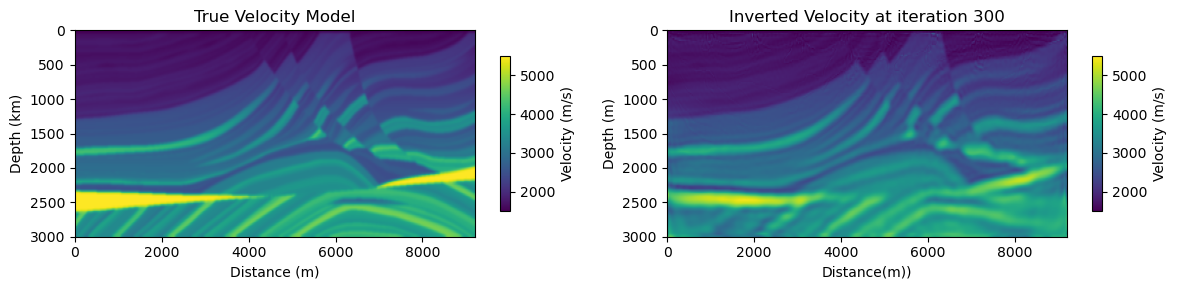

Epoch 301: loss=0.00034, v_min=1480.0, v_max=5396.6
Epoch 302: loss=0.00033, v_min=1480.0, v_max=5397.6
Epoch 303: loss=0.00033, v_min=1480.0, v_max=5398.7
Epoch 304: loss=0.00033, v_min=1480.0, v_max=5399.7
Epoch 305: loss=0.00032, v_min=1480.0, v_max=5400.7
Epoch 306: loss=0.00032, v_min=1480.0, v_max=5401.8
Epoch 307: loss=0.00032, v_min=1480.0, v_max=5402.8
Epoch 308: loss=0.00032, v_min=1480.0, v_max=5403.8
Epoch 309: loss=0.00033, v_min=1480.2, v_max=5404.8
Epoch 310: loss=0.00034, v_min=1480.0, v_max=5405.8
Epoch 311: loss=0.00035, v_min=1480.0, v_max=5406.8
Epoch 312: loss=0.00037, v_min=1480.0, v_max=5407.8
Epoch 313: loss=0.00044, v_min=1480.3, v_max=5408.8
Epoch 314: loss=0.00052, v_min=1480.0, v_max=5409.7
Epoch 315: loss=0.00068, v_min=1480.0, v_max=5410.8
Epoch 316: loss=0.00104, v_min=1480.0, v_max=5411.7
Epoch 317: loss=0.00170, v_min=1482.2, v_max=5412.8
Epoch 318: loss=0.00319, v_min=1480.0, v_max=5413.6
Epoch 319: loss=0.00596, v_min=1480.0, v_max=5414.7
Epoch 320: l

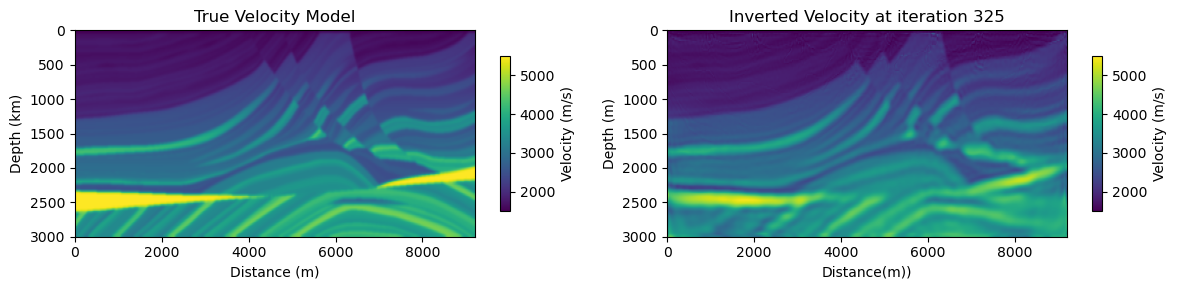

Epoch 326: loss=0.00128, v_min=1480.0, v_max=5417.7
Epoch 327: loss=0.00555, v_min=1480.0, v_max=5417.8
Epoch 328: loss=0.01718, v_min=1480.0, v_max=5418.6
Epoch 329: loss=0.02373, v_min=1480.0, v_max=5418.5
Epoch 330: loss=0.01641, v_min=1481.1, v_max=5419.1
Epoch 331: loss=0.00435, v_min=1480.5, v_max=5419.4
Epoch 332: loss=0.00120, v_min=1480.0, v_max=5419.7
Epoch 333: loss=0.00733, v_min=1480.0, v_max=5420.6
Epoch 334: loss=0.01330, v_min=1480.0, v_max=5420.8
Epoch 335: loss=0.01379, v_min=1480.0, v_max=5421.6
Epoch 336: loss=0.00620, v_min=1480.1, v_max=5421.9
Epoch 337: loss=0.00160, v_min=1480.0, v_max=5422.3
Epoch 338: loss=0.00493, v_min=1480.0, v_max=5423.1
Epoch 339: loss=0.00791, v_min=1480.0, v_max=5423.4
Epoch 340: loss=0.00867, v_min=1480.0, v_max=5424.2
Epoch 341: loss=0.00496, v_min=1480.0, v_max=5424.7
Epoch 342: loss=0.00168, v_min=1480.0, v_max=5425.2
Epoch 343: loss=0.00503, v_min=1480.0, v_max=5426.1
Epoch 344: loss=0.00682, v_min=1480.0, v_max=5426.6
Epoch 345: l

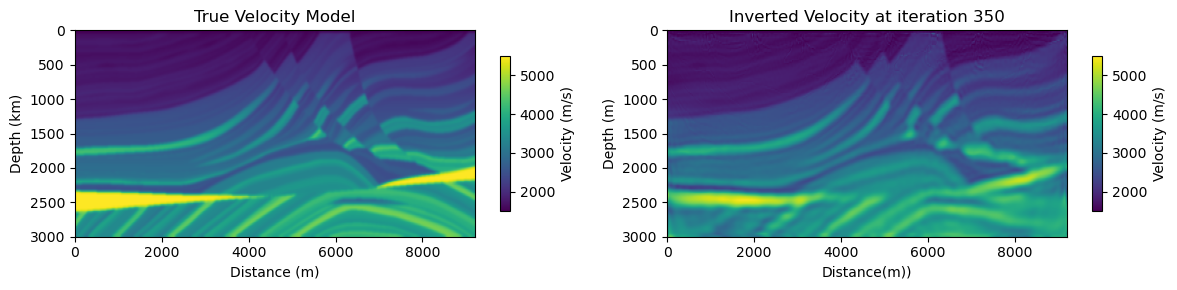

Epoch 351: loss=0.00242, v_min=1480.0, v_max=5432.4
Epoch 352: loss=0.00308, v_min=1480.0, v_max=5433.3
Epoch 353: loss=0.00443, v_min=1480.0, v_max=5434.5
Epoch 354: loss=0.00362, v_min=1480.0, v_max=5435.3
Epoch 355: loss=0.00339, v_min=1480.0, v_max=5436.4
Epoch 356: loss=0.00290, v_min=1480.0, v_max=5437.5
Epoch 357: loss=0.00338, v_min=1480.0, v_max=5438.5
Epoch 358: loss=0.00392, v_min=1480.0, v_max=5439.7
Epoch 359: loss=0.00369, v_min=1480.0, v_max=5440.6
Epoch 360: loss=0.00352, v_min=1480.0, v_max=5441.8
Epoch 361: loss=0.00270, v_min=1480.0, v_max=5443.0
Epoch 362: loss=0.00302, v_min=1480.0, v_max=5444.1
Epoch 363: loss=0.00317, v_min=1480.0, v_max=5445.5
Epoch 364: loss=0.00305, v_min=1480.0, v_max=5446.6
Epoch 365: loss=0.00242, v_min=1480.0, v_max=5447.8
Epoch 366: loss=0.00243, v_min=1480.0, v_max=5449.0
Epoch 367: loss=0.00247, v_min=1480.0, v_max=5450.1
Epoch 368: loss=0.00255, v_min=1480.0, v_max=5451.3
Epoch 369: loss=0.00232, v_min=1480.0, v_max=5452.4
Epoch 370: l

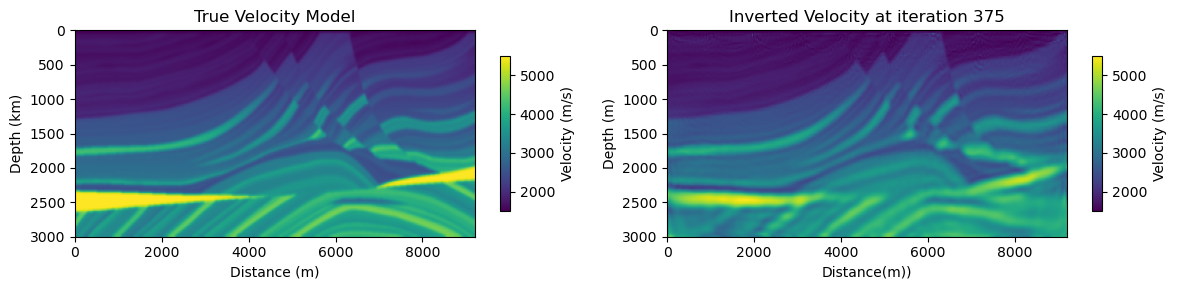

Epoch 376: loss=0.00160, v_min=1480.0, v_max=5459.5
Epoch 377: loss=0.00148, v_min=1480.0, v_max=5460.3
Epoch 378: loss=0.00165, v_min=1480.0, v_max=5461.1
Epoch 379: loss=0.00156, v_min=1480.0, v_max=5461.7
Epoch 380: loss=0.00141, v_min=1480.0, v_max=5462.4
Epoch 381: loss=0.00128, v_min=1480.0, v_max=5463.2
Epoch 382: loss=0.00118, v_min=1480.0, v_max=5464.1
Epoch 383: loss=0.00110, v_min=1480.0, v_max=5465.1
Epoch 384: loss=0.00111, v_min=1480.0, v_max=5466.1
Epoch 385: loss=0.00107, v_min=1480.0, v_max=5467.3
Epoch 386: loss=0.00099, v_min=1480.0, v_max=5468.3
Epoch 387: loss=0.00088, v_min=1480.0, v_max=5469.3
Epoch 388: loss=0.00080, v_min=1480.0, v_max=5470.4
Epoch 389: loss=0.00086, v_min=1480.0, v_max=5471.3
Epoch 390: loss=0.00081, v_min=1480.0, v_max=5472.4
Epoch 391: loss=0.00080, v_min=1480.0, v_max=5473.3
Epoch 392: loss=0.00075, v_min=1480.0, v_max=5474.3
Epoch 393: loss=0.00068, v_min=1480.0, v_max=5475.2
Epoch 394: loss=0.00064, v_min=1480.0, v_max=5476.1
Epoch 395: l

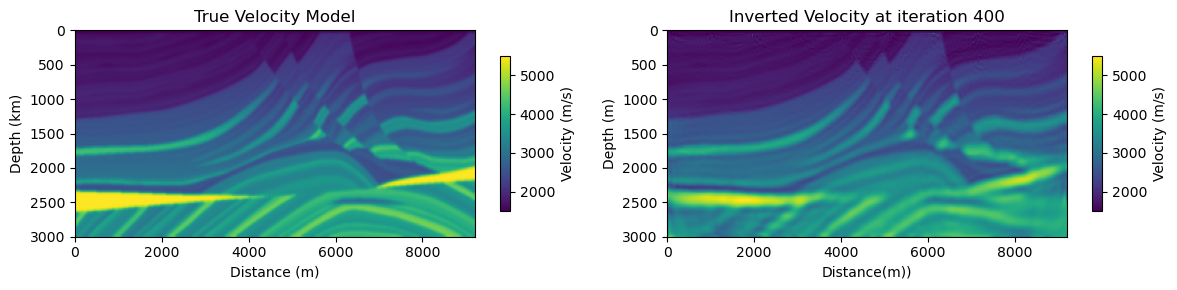

In [6]:
## INVERSION 

# We track the gradient of the velocity
v1.requires_grad_()  

# Velocity limits used for plotting
vmin = v_true.min()
vmax = v_true.max()

optimiser = torch.optim.Adam([v1], lr=1e2) 
n_epochs = 400

# OPTIMIZATION LOOP
losses = []
gradients = []

for epoch in range(n_epochs):
    optimiser.zero_grad()
    out_vel_1 = scalar(
        v1, dx, dt,
        source_amplitudes=source_amp,
        source_locations=source_loc,
        receiver_locations=receiver_loc,
        pml_freq= freq
    )
    loss = loss_fn(taper(out_vel_1[-1]), observed_data_1)
    loss.backward()               # gradient computation
    
    # Gradient smoothing 
    with torch.no_grad():
        grad = v1.grad.detach().cpu().numpy()
        grad_smoothed = gaussian_filter(grad, sigma=1)
        v1.grad.copy_(torch.tensor(grad_smoothed).to(v1.device))

    # clip the gradients
    torch.nn.utils.clip_grad_value_(
        v1,
        torch.quantile(v1.grad.detach().abs(), 0.98)
    )
    optimiser.step()   # Update

    # Clamp model values to stay within physical limits
    with torch.no_grad():
        v1.clamp_(min=1480.0, max=5800.0)

    losses.append(loss.item())      # store the losses
    gradients.append(v1.grad.clone().detach().cpu())   # store the gradients

    # Print info
    print(f"Epoch {epoch+1}: loss={loss.item():.5f}, v_min={v1.min().item():.1f}, v_max={v1.max().item():.1f}")

    # Visualise evolution of the inversion 
    if (epoch+1) % 25 == 0:
        vel = v1.clone()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

        # Plot 1: True Velocity
        im1 = ax1.imshow(v_true.cpu().T, vmin=vmin, vmax=vmax, cmap='viridis', 
                   aspect='auto', extent=extent)
        ax1.set_title(f'True Velocity Model')
        ax1.set_xlabel("Distance (m)")
        ax1.set_ylabel("Depth (km)")

        # Plot 2: Inverted Velocity
        im2 = ax2.imshow(vel.detach().cpu().T, vmin=vmin, vmax=vmax, cmap='viridis', 
                        aspect='auto', extent=extent)
        ax2.set_title(f'Inverted Velocity at iteration {epoch+1}')
        ax2.set_xlabel("Distance(m))")
        ax2.set_ylabel("Depth (m)")

        fig.colorbar(im1, ax=ax1, label='Velocity (m/s)', 
                     shrink=0.75, aspect=15, pad=0.05)
        fig.colorbar(im2, ax=ax2, label='Velocity (m/s)', 
                     shrink=0.75, aspect=15, pad=0.05)
        
        plt.tight_layout()
        plt.show()


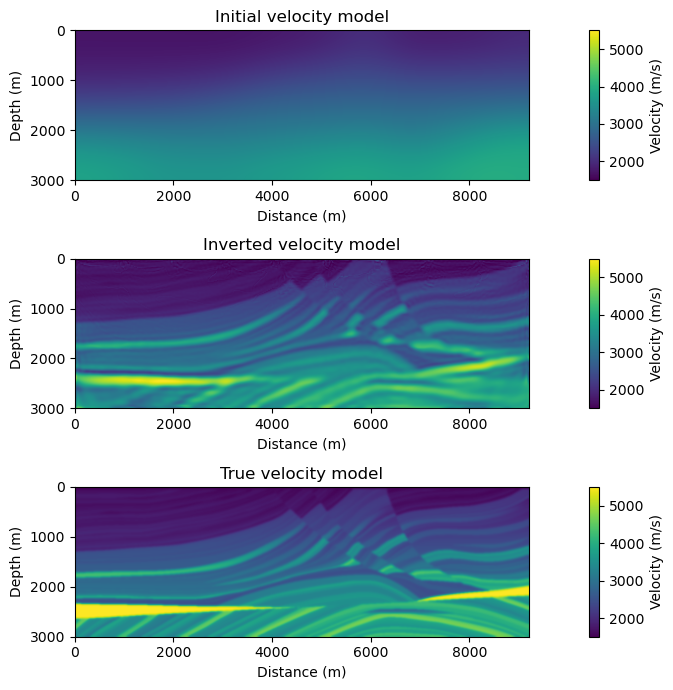

In [7]:
# PLOTTING THE RESULTS OF THE LOCAL INVERSION

fig1, ax1 = plt.subplots(3, figsize=(7, 7))
im0 = ax1[0].imshow(v_init.cpu().T, aspect='auto', cmap='viridis',
             vmin= vmin, vmax=vmax, extent=extent)
ax1[0].set_title("Initial velocity model")
ax1[0].set_xlabel("Distance (m)")
ax1[0].set_ylabel("Depth (m)")
fig1.colorbar(im0, ax = ax1[0], shrink = 1, aspect = 15, pad = 0.1, label='Velocity (m/s)' )

im1 = ax1[1].imshow(v1.detach().cpu().T, aspect='auto', cmap='viridis',
             vmin= vmin, vmax=vmax, extent=extent)
ax1[1].set_title(f"Inverted velocity model")
ax1[1].set_xlabel("Distance (m)")
ax1[1].set_ylabel("Depth (m)")
fig1.colorbar(im1, ax = ax1[1], shrink = 1, aspect = 15, pad = 0.1, label='Velocity (m/s)' )

im2 = ax1[2].imshow(v_true.cpu().T, aspect='auto', cmap='viridis',
             vmin= vmin, vmax=vmax, extent=extent)
ax1[2].set_title("True velocity model")
ax1[2].set_xlabel("Distance (m)")
ax1[2].set_ylabel("Depth (m)")
fig1.colorbar(im2, ax = ax1[2], shrink = 1, aspect = 15, pad = 0.1, label='Velocity (m/s)' )

plt.tight_layout()
# plt.savefig("result_fwi_marmousi.png", dpi=300)  # uncomment to save the result


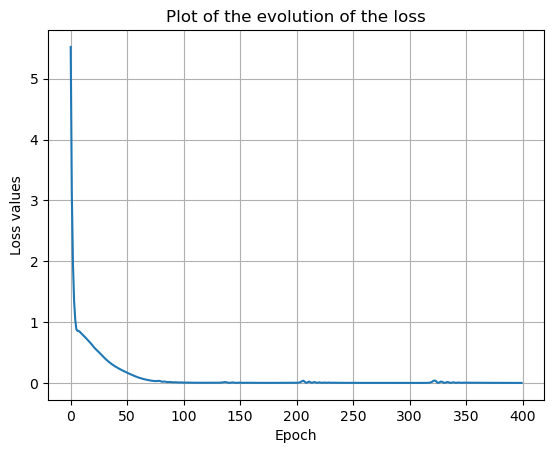

In [8]:
#PLOT THE LOSS VALUES
plt.figure()
plt.plot(losses)
plt.title("Plot of the evolution of the loss")
plt.xlabel("Epoch")
plt.ylabel("Loss values")
plt.grid()
plt.show()


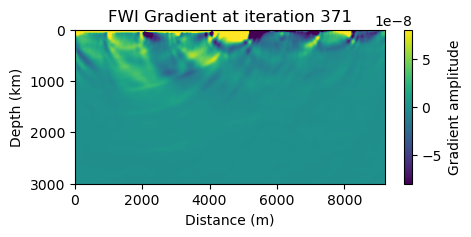

In [9]:
#PLOT OF THE GRADIENTS

k = np.random.randint(n_epochs)
plt.figure(figsize=(5, 2))
plt.imshow(gradients[k].cpu().T, cmap='viridis', aspect='auto', extent=extent)
plt.title(f"FWI Gradient at iteration { k+ 1}")
plt.xlabel("Distance (m)")
plt.ylabel("Depth (km)")
plt.colorbar(label='Gradient amplitude')
plt.show()